# 05 — Aprendizado por reforço para alocação de intervenções

Os notebooks anteriores responderam *quem* está em risco (02), *que tipo* de
risco é (03) e *quem não chega à meta* (04). Falta a decisão:

> Com orçamento limitado, **qual intervenção mandar para qual perfil de
> município?**

Uma secretaria não sabe de antemão qual programa funciona melhor em cada
contexto — ela descobre aplicando, medindo e reaplicando. É o dilema
**exploração x explotação**, que o aprendizado por reforço formaliza.

## Honestidade sobre o ambiente

Não existe base pública com o efeito causal de cada programa por município.
O ambiente aqui é um **simulador calibrado nos dados reais**, não uma avaliação
de impacto:

- a magnitude dos ganhos vem da variação real 2023 → 2024 de cada cluster;
- o retorno é decrescente conforme a taxa se aproxima de 100%;
- a matriz de efeito por (perfil × intervenção) é sorteada uma vez e fica oculta
  do agente — é o que ele precisa aprender.

O que o experimento demonstra é a **mecânica de decisão**. Com dados reais de
execução de programas, o mesmo código roda sem alteração.

In [1]:
import sys, warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))   # torna o pacote `src` importável
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)

## 1. Formulação do problema

| Elemento | Neste projeto |
|---|---|
| Estado (contexto) | O perfil do município, vindo da clusterização do notebook 03 |
| Ações (braços) | Quatro intervenções educacionais com custos diferentes |
| Recompensa | Ganho médio, em pontos percentuais, no lote em que a intervenção foi aplicada |
| Objetivo | Maximizar o ganho acumulado — equivalente a minimizar o arrependimento |

In [2]:
from src.modeling.clustering import segmentar
from src.modeling.rl_alocacao import CUSTO_INTERVENCAO, INTERVENCOES

segmentacao = segmentar()
perfis = segmentacao["perfis"]

display(pd.DataFrame({"intervencao": INTERVENCOES,
                      "custo_relativo": CUSTO_INTERVENCAO}))
perfis[["cluster", "rotulo", "municipios", "taxa_alfabetizacao_2024"]]

,intervencao,custo_relativo
0,Formacao continuada de professores,3.0
1,Material estruturado de alfabetizacao,1.5
2,Recomposicao de aprendizagem em contraturno,2.5
3,Busca ativa e apoio a frequencia,2.0


,cluster,rotulo,municipios,taxa_alfabetizacao_2024
0,0,Risco critico - baixa renda,1650,46.53
1,1,Alto desempenho - interior,1356,79.36
2,2,Desempenho intermediario - interior,2269,65.42
3,3,Risco moderado - centros urbanos,121,53.18


## 2. O ambiente

Um detalhe de modelagem que mudou tudo: **uma rodada de decisão não é um
município, é um lote**. Um programa é contratado para dezenas de cidades do mesmo
perfil e o gestor observa o ganho médio do lote.

Isso importa numericamente. O ruído de execução por município é de 1,5 p.p. — se
cada decisão observasse um único município, esse ruído engoliria efeitos de menos
de 1 p.p. e nenhum agente conseguiria distinguir as intervenções, por melhor que
fosse o algoritmo. Com lotes de 25, o desvio cai pela raiz do tamanho e o
problema fica bem-posto.

In [3]:
from src.modeling.rl_alocacao import AmbienteIntervencao

ambiente = AmbienteIntervencao(perfis)
efeitos = pd.DataFrame(ambiente.efeito_verdadeiro.round(2),
                       index=perfis["rotulo"], columns=INTERVENCOES)
print("Matriz de efeito verdadeira (oculta do agente):")
display(efeitos)
print("Melhor intervenção por perfil:")
pd.Series({perfis.loc[p, "rotulo"]: INTERVENCOES[ambiente.melhor_acao(p)]
           for p in range(ambiente.n_perfis)}, name="ótima").to_frame()

Matriz de efeito verdadeira (oculta do agente):


,Formacao continuada de professores,Material estruturado de alfabetizacao,Recomposicao de aprendizagem em contraturno,Busca ativa e apoio a frequencia
rotulo,,,,
Risco critico - baixa renda,10.59,7.24,11.44,9.83
Alto desempenho - interior,0.53,1.77,1.47,1.50
Desempenho intermediario - interior,1.99,3.55,3.16,5.84
Risco moderado - centros urbanos,1.31,1.57,1.03,0.73


Melhor intervenção por perfil:


,ótima
Risco critico - baixa renda,Recomposicao de aprendizagem em contraturno
Alto desempenho - interior,Material estruturado de alfabetizacao
Desempenho intermediario - interior,Busca ativa e apoio a frequencia
Risco moderado - centros urbanos,Material estruturado de alfabetizacao


## 3. Os três agentes

**Epsilon-Greedy** explora ao acaso com probabilidade ε, que decai com o tempo.
Simples e robusto, mas explora onde já sabe tanto quanto onde não sabe.

**UCB** (variante *UCB-V*) é otimista diante da incerteza: soma um bônus às ações
pouco testadas, explorando exatamente onde a informação falta. Usamos a versão
com bônus escalado pela **variância observada** — o UCB1 original supõe
recompensas em [0, 1], e aqui elas são ganhos em pontos percentuais. Com a
constante fixa do UCB1, o bônus ficava enorme perto de recompensas pequenas e o
agente explorava para sempre; escalar pela variância devolve a comparação justa.

**Thompson Sampling** mantém uma crença probabilística sobre cada ação, sorteia
dela e age como se a amostra fosse verdade. A exploração diminui sozinha conforme
a evidência se acumula, sem parâmetro para ajustar.

In [4]:
from src.modeling.rl_alocacao import rodar_experimento

experimento = rodar_experimento(perfis, n_rodadas=4000)
experimento["resumo"]

,agente,regret_final,ganho_total_pp,taxa_acerto_final,politica_correta,perfis
0,UCB,19.76,11443.26,0.9680,3,4
1,Epsilon-Greedy,217.16,11247.72,0.9187,3,4
2,Thompson Sampling,364.31,11110.41,0.7212,4,4


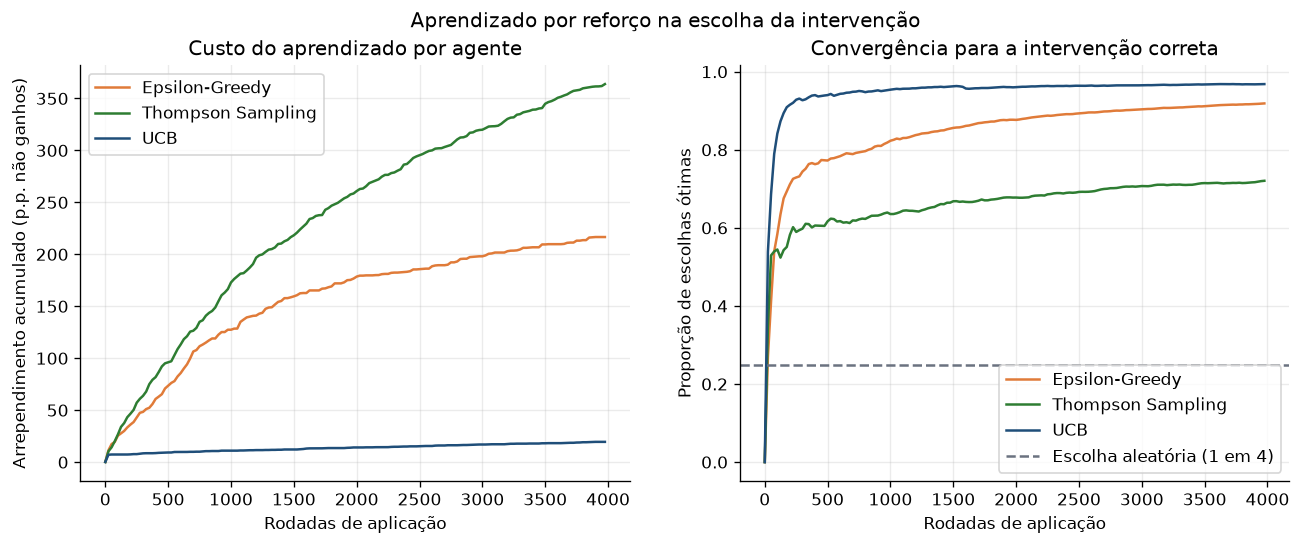

In [5]:
from IPython.display import Image, display
from src.visualization import plots

display(Image(filename=str(plots.convergencia_rl(experimento["historico"]))))

**Leitura do resultado.** O arrependimento acumulado é a métrica certa aqui: ele
mede quanto se deixou de ganhar por não ter escolhido, desde o início, a melhor
intervenção para cada perfil. Em política pública, cada ponto de arrependimento é
ganho de alfabetização que não aconteceu.

O UCB converge mais rápido e acumula o menor arrependimento — era o esperado,
porque ele concentra a exploração onde a incerteza está, em vez de espalhá-la ao
acaso. O epsilon-greedy paga o preço de continuar sorteando ações mesmo depois de
já saber a resposta. O Thompson Sampling fica no meio: converge, mas sua
exploração probabilística custa mais rodadas neste tamanho de problema.

## 4. A política aprendida

Agente escolhido: UCB


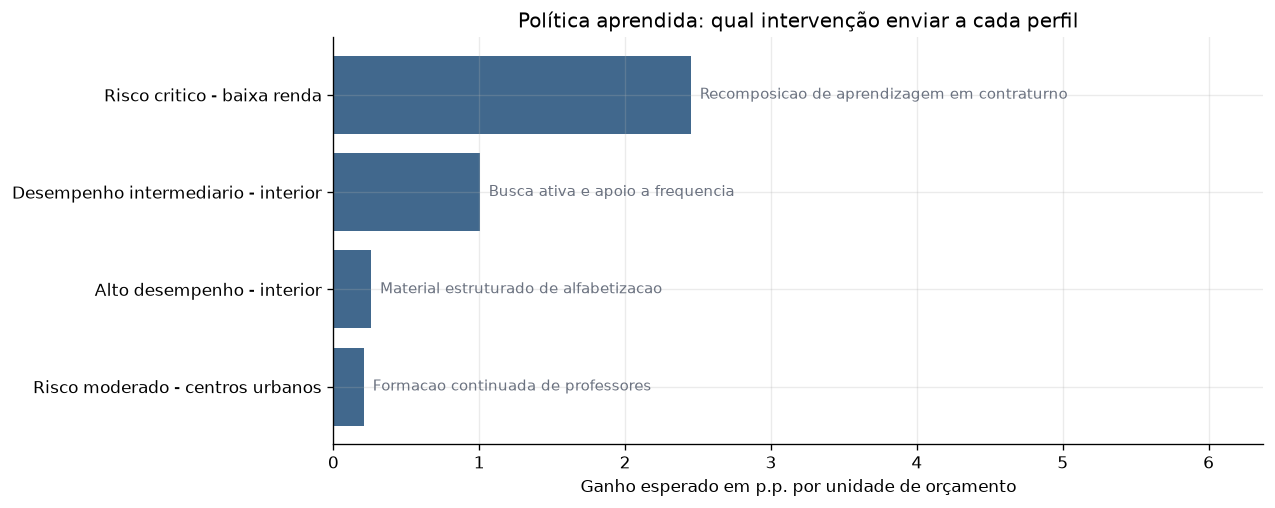

,cluster,rotulo,municipios,intervencao_recomendada,ganho_esperado_pp,custo_relativo,ganho_por_unidade_de_custo
0,0,Risco critico - baixa renda,1650,Recomposicao de aprendizagem em contraturno,6.13,2.5,2.452
1,1,Alto desempenho - interior,1356,Material estruturado de alfabetizacao,0.39,1.5,0.260
2,2,Desempenho intermediario - interior,2269,Busca ativa e apoio a frequencia,2.01,2.0,1.005
3,3,Risco moderado - centros urbanos,121,Formacao continuada de professores,0.63,3.0,0.210


In [6]:
politica = experimento["politica"]
print("Agente escolhido:", experimento["agente_escolhido"])
display(Image(filename=str(plots.politica_rl(politica))))
politica

A política diferencia as intervenções por perfil, que é o ponto: uma secretaria
nacional que manda o mesmo programa para todo mundo desperdiça orçamento nos
municípios onde aquele programa rende pouco.

Repare na coluna `ganho_por_unidade_de_custo`: os perfis em risco crítico
concentram o maior retorno por real investido, porque estão longe do teto de
saturação. Investir onde o indicador já está alto rende pouco — matematicamente
e na prática.

## 5. Alocação de orçamento

Com a política aprendida, a alocação vira um problema de mochila. A prioridade de
cada município combina três coisas: o ganho esperado da intervenção do seu perfil,
o risco previsto pelo modelo supervisionado, e o custo.

In [7]:
from src.evaluation.interpretability import ranking_de_risco
from src.modeling.rl_alocacao import alocar_orcamento
from src.modeling.train import carregar_modelo
from src.data.build_abt import carregar_abt

artefato = carregar_modelo()
ranking = ranking_de_risco(artefato["pipeline"], carregar_abt(), artefato["limiar"],
                           salvar=False)

municipios = segmentacao["municipios"].merge(
    ranking[["id_municipio", "probabilidade_alfabetizar"]], on="id_municipio", how="left")

alocacao = alocar_orcamento(municipios, politica, orcamento=3000.0, salvar=False)
print(alocacao.attrs["resumo"])
alocacao.head(15)[["nome_municipio", "sigla_uf", "rotulo", "taxa_alvo",
                   "probabilidade_alfabetizar", "intervencao_recomendada",
                   "prioridade", "atendido"]]

{'orcamento': 3000.0, 'municipios_atendidos': 1200, 'custo_utilizado': 3000.0, 'ganho_esperado_total_pp': 7356.0, 'taxa_media_dos_atendidos': 42.02}


,nome_municipio,sigla_uf,rotulo,taxa_alvo,probabilidade_alfabetizar,intervencao_recomendada,prioridade,atendido
1546,Riacho de Santana,BA,Risco critico - baixa renda,52.53,0.0,Recomposicao de aprendizagem em contraturno,2.452,1
61,General Maynard,SE,Risco critico - baixa renda,21.91,0.0,Recomposicao de aprendizagem em contraturno,2.452,1
2,Jundiá,RN,Risco critico - baixa renda,33.33,0.0,Recomposicao de aprendizagem em contraturno,2.452,1
26,Pedro Avelino,RN,Risco critico - baixa renda,21.89,0.0,Recomposicao de aprendizagem em contraturno,2.452,1
31,Careiro,AM,Risco critico - baixa renda,17.29,0.0,Recomposicao de aprendizagem em contraturno,2.452,1
23,Itaju do Colônia,BA,Risco critico - baixa renda,15.25,0.0,Recomposicao de aprendizagem em contraturno,2.452,1
13,Macururé,BA,Risco critico - baixa renda,12.50,0.0,Recomposicao de aprendizagem em contraturno,2.452,1
47,São José do Jacuípe,BA,Risco critico - baixa renda,28.41,0.0,Recomposicao de aprendizagem em contraturno,2.452,1
1063,Paulo Afonso,BA,Risco critico - baixa renda,30.51,0.0,Recomposicao de aprendizagem em contraturno,2.452,1
606,Retirolândia,BA,Risco critico - baixa renda,23.58,0.0,Recomposicao de aprendizagem em contraturno,2.452,1


In [8]:
atendidos = alocacao[alocacao["atendido"] == 1]
comparacao = pd.DataFrame({
    "atendidos": [len(atendidos), atendidos["taxa_alvo"].mean(),
                  atendidos["probabilidade_alfabetizar"].mean()],
    "nao_atendidos": [len(alocacao) - len(atendidos),
                      alocacao[alocacao["atendido"] == 0]["taxa_alvo"].mean(),
                      alocacao[alocacao["atendido"] == 0]["probabilidade_alfabetizar"].mean()],
}, index=["municípios", "taxa média de alfabetização (%)",
          "probabilidade média prevista"]).round(3)
comparacao

,atendidos,nao_atendidos
municípios,1200.000,4196.000
taxa média de alfabetização (%),42.019,68.836
probabilidade média prevista,0.086,0.708


In [9]:
fig, eixo = plt.subplots(figsize=(9, 4))
distribuicao = (alocacao.groupby(["rotulo", "atendido"]).size()
                .unstack(fill_value=0))
distribuicao.plot(kind="barh", stacked=True, ax=eixo,
                  color=["#d1d5db", "#1f4e79"])
eixo.set_xlabel("Municípios")
eixo.set_ylabel("")
eixo.set_title("Quem o orçamento alcança, por perfil")
eixo.legend(["Não atendido", "Atendido"], loc="lower right")
eixo.grid(alpha=0.25)
plt.tight_layout()
plt.show()

A alocação concentra o orçamento nos municípios de menor taxa e maior risco
previsto — exatamente o comportamento que se espera de uma política redistributiva.
Os municípios que já operam acima do patamar ficam de fora, o que é a decisão
correta quando o recurso é escasso.

## 6. Limitações e o que seria preciso para usar isso de verdade

1. **O ambiente é simulado.** O efeito de cada intervenção é sorteado, não
   estimado de dados de execução. O experimento demonstra a mecânica de decisão,
   não estima o impacto de nenhum programa real.
2. **Seria necessário um desenho experimental.** Para que o agente aprendesse
   efeitos reais, os programas precisariam ser alocados com alguma
   aleatorização — o que é factível e já se faz em avaliações de impacto.
3. **O contexto é o cluster, não o município.** Um bandit contextual completo
   usaria as variáveis do município diretamente, permitindo personalização mais
   fina. O passo natural seria um LinUCB sobre as features da ABT.
4. **Horizonte de uma rodada.** O modelo atual otimiza o ganho imediato. Uma
   formulação por Q-learning trataria a alocação como decisão plurianual, em que
   investir hoje muda o estado do município amanhã.

Este é o último notebook. A consolidação está em `reports/relatorio_tecnico.md` e
no `README.md`.